# import library

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import entropy

# merge data

In [ ]:
data_path = '/home/agung/Documents/alcr/ABC2026 Sozolab Challenge-20260110T085845Z-1-001/ABC2026 Sozolab Challenge/Dataset/BLE Data'

file_name = '4 day'

rssi_list = ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16', '17','18','19','20', '21','22', '23','24','25']

mac_list = ['F7:7F:78:76:7E:F3',
            'C6:CD:5E:3D:2F:BB',
            'D6:F4:3A:79:74:63',
            'C9:17:55:E2:3E:0E',
            'CA:60:AB:EE:EC:7F',
            'D6:51:7F:AB:0E:29',
            'CC:54:33:F6:A7:90',
            'EB:20:56:87:04:5A',
            'EE:E7:46:DC:19:6F',
            'C8:5B:BF:37:07:A0',
            'D7:26:F6:A3:44:D2',
            'DD:83:B0:27:FD:36',
            'E5:CD:4A:36:87:06',
            'DC:22:B8:17:4E:B5',
            'EA:09:20:80:D6:44',
            'E6:99:D1:EC:C6:81',
            'F6:DA:97:C7:D5:28',
            'EA:66:A1:12:2C:F4',
            'C9:EA:57:8B:0F:80',
            'D6:7C:1D:2C:2A:0A',
            'DA:E1:70:5F:44:97',
            'DD:10:10:F6:4F:27',
            'E6:F3:93:A8:9E:22',
            'E6:60:05:1F:88:F9',
            'D4:33:FD:F4:C2:A8']

file_list = os.listdir(data_path)

csv_data = []
for csv_file in file_list:
  csv_data.append(pd.read_csv(os.path.join(data_path,csv_file),names=['user_id','timestamp','name', 'mac address', 'RSSI', 'power']))

df = csv_data[0]
for i in range(1,len(csv_data)):
  df = pd.concat([df,csv_data[i]])

print(df.shape)
df.head(5)

In [ ]:
# df.to_csv('df_concatenated.csv', index=False)

# load data

In [ ]:
df = pd.read_csv('../../dataset/df_concatenated.csv')
label = pd.read_csv('../../dataset/Dataset/5f_label_loc_train.csv')

# eda

In [ ]:
print(df.info())

print(label.info())

## rssi

In [ ]:
df.head(1)

In [ ]:
print(df['user_id'].value_counts())
print(df['name'].value_counts())

In [ ]:
print(df['mac address'].nunique())
print(df['power'].nunique())
print(df['RSSI'].nunique())

In [ ]:
plt.hist(df['power'])

In [ ]:
plt.hist(df['RSSI'])

## label

In [ ]:
label.head(1)

In [ ]:
print(label['activity'].value_counts())
print(label['user_id'].value_counts())
print(label['user'].value_counts())
print(label['room'].value_counts())
print(label['floor'].value_counts())

# preprocessing

## cleaning

In [ ]:
df = df.drop(columns=['name'])

label = label.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'user', 'floor'])

In [ ]:
# rename agar jelas
label = label.rename(columns={
    'started_at': 'start_time',
    'finished_at': 'stop_time'
})

# parse waktu
label['start_time'] = pd.to_datetime(label['start_time'], errors='coerce')
label['stop_time']  = pd.to_datetime(label['stop_time'], errors='coerce')

# hitung durasi
label['duration'] = (label['stop_time'] - label['start_time']).dt.total_seconds()

# filter valid
label = label[
    label['start_time'].notna() &
    label['stop_time'].notna() &
    (label['duration'] > 0) &
    label['deleted_at'].isna()
]

# hapus null penting & duplikat
label = label.dropna(subset=['room'])
label = label.drop_duplicates()

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df[df['timestamp'].notna()]

In [ ]:
df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Tokyo')
label['start_time'] = label['start_time'].dt.tz_convert('Asia/Tokyo')
label['stop_time'] = label['stop_time'].dt.tz_convert('Asia/Tokyo')

In [ ]:
label = label.loc[label['activity'] == 'Location']
label = label.drop(columns=['deleted_at', 'updated_at', 'activity'])

In [ ]:
df = df.sort_values('timestamp').reset_index(drop=True)
label = label.sort_values('start_time').reset_index(drop=True)

In [ ]:
# ambil rentang label
start_label = label['start_time'].min()
end_label = label['stop_time'].max()

# potong RSSI ke rentang label
df = df[(df['timestamp'] >= start_label) & (df['timestamp'] <= end_label)].copy()

print(df['timestamp'].min(), df['timestamp'].max())

In [ ]:
print(start_label)
print(end_label)

In [ ]:
rooms = []
lbl = label.to_dict('records')
j = 0
n = len(lbl)

for ts in df['timestamp']:
    # geser interval label sampai stop_time >= ts
    while j < n and ts > lbl[j]['stop_time']:
        j += 1

    if j < n and lbl[j]['start_time'] <= ts <= lbl[j]['stop_time']:
        rooms.append(lbl[j]['room'])
    else:
        rooms.append(np.nan)

df['room'] = rooms

# buang RSSI tanpa label
df1 = df.dropna(subset=['room']).reset_index(drop=True)


In [ ]:
print(df1.shape)
print(df1['room'].value_counts())

In [ ]:
df1.info()

In [ ]:
df1.to_csv('../../dataset/df_cleaned.csv')

## feature engineering

In [117]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import entropy

In [118]:
df = pd.read_csv('../../dataset/df_cleaned.csv')

In [119]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df[df['timestamp'].notna()]
df = df.drop(columns=['Unnamed: 0'])

In [120]:
mac_list = ['F7:7F:78:76:7E:F3',
            'C6:CD:5E:3D:2F:BB',
            'D6:F4:3A:79:74:63',
            'C9:17:55:E2:3E:0E',
            'CA:60:AB:EE:EC:7F',
            'D6:51:7F:AB:0E:29',
            'CC:54:33:F6:A7:90',
            'EB:20:56:87:04:5A',
            'EE:E7:46:DC:19:6F',
            'C8:5B:BF:37:07:A0',
            'D7:26:F6:A3:44:D2',
            'DD:83:B0:27:FD:36',
            'E5:CD:4A:36:87:06',
            'DC:22:B8:17:4E:B5',
            'EA:09:20:80:D6:44',
            'E6:99:D1:EC:C6:81',
            'F6:DA:97:C7:D5:28',
            'EA:66:A1:12:2C:F4',
            'C9:EA:57:8B:0F:80',
            'D6:7C:1D:2C:2A:0A',
            'DA:E1:70:5F:44:97',
            'DD:10:10:F6:4F:27',
            'E6:F3:93:A8:9E:22',
            'E6:60:05:1F:88:F9',
            'D4:33:FD:F4:C2:A8']

df = df[df['mac address'].isin(mac_list)]
df = df.sort_values('timestamp').reset_index(drop=True)

In [121]:
WINDOW = '45s'
df['window_start'] = df['timestamp'].dt.floor(WINDOW)

room_per_window = (
    df.groupby('window_start')['room']
      .nunique()
      .value_counts()
)

room_per_window

room
1    729
2    175
3     35
4      4
5      1
Name: count, dtype: int64

In [122]:
valid_windows = (
    df.groupby('window_start')['room']
      .nunique()
      .reset_index()
)

valid_windows = valid_windows[valid_windows['room'] == 1]['window_start']

df = df[df['window_start'].isin(valid_windows)].reset_index(drop=True)

df.groupby('window_start')['room'].nunique().value_counts()

room
1    729
Name: count, dtype: int64

In [123]:
# RSSI matrix: window x beacon
rssi_matrix = (
    df
    .groupby(['window_start', 'mac address'])['RSSI']
    .mean()              
    .unstack('mac address')
    .sort_index()
)

In [124]:
rssi_matrix.head()

mac address,C6:CD:5E:3D:2F:BB,C8:5B:BF:37:07:A0,C9:17:55:E2:3E:0E,C9:EA:57:8B:0F:80,CA:60:AB:EE:EC:7F,CC:54:33:F6:A7:90,D4:33:FD:F4:C2:A8,D6:51:7F:AB:0E:29,D6:7C:1D:2C:2A:0A,D6:F4:3A:79:74:63,...,E5:CD:4A:36:87:06,E6:60:05:1F:88:F9,E6:99:D1:EC:C6:81,E6:F3:93:A8:9E:22,EA:09:20:80:D6:44,EA:66:A1:12:2C:F4,EB:20:56:87:04:5A,EE:E7:46:DC:19:6F,F6:DA:97:C7:D5:28,F7:7F:78:76:7E:F3
window_start,,,,,,,,,,,,,,,,,,,,,
2023-04-10 14:22:30+09:00,NaN,NaN,-94.812375,NaN,NaN,NaN,NaN,-96.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-04-10 14:24:45+09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-99.000000,NaN,NaN,NaN,NaN,-98.00
2023-04-10 14:25:30+09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-96.545455,NaN,-100.0,NaN,-96.213018,NaN,NaN,NaN,NaN,-96.75
2023-04-10 14:28:30+09:00,NaN,NaN,NaN,-91.780822,-93.512195,NaN,NaN,-93.522184,NaN,NaN,...,NaN,NaN,-99.0,NaN,NaN,NaN,NaN,-97.571429,-98.166667,NaN
2023-04-10 14:30:00+09:00,NaN,-91.714286,NaN,NaN,NaN,NaN,NaN,NaN,-86.2,NaN,...,NaN,NaN,NaN,NaN,NaN,-97.5,-92.428571,NaN,NaN,NaN


In [125]:
agg_funcs = ['mean', 'std', 'var', 'min', 'max', 'median', 'sum', 'count']

feat = (
    df
    .groupby(['window_start', 'room', 'mac address'])['RSSI']
    .agg(agg_funcs)
    .unstack('mac address')
)

# flatten kolom: {mac}_{stat}
feat.columns = [f'{mac}_{stat}' for stat, mac in feat.columns]
feat = feat.reset_index()

In [126]:
feat['hour'] = feat['window_start'].dt.hour
feat['minute'] = feat['window_start'].dt.minute
feat['second'] = feat['window_start'].dt.second

In [127]:
feat = feat.fillna(0)

In [128]:
feat.columns.tolist()

['window_start',
 'room',
 'C6:CD:5E:3D:2F:BB_mean',
 'C8:5B:BF:37:07:A0_mean',
 'C9:17:55:E2:3E:0E_mean',
 'C9:EA:57:8B:0F:80_mean',
 'CA:60:AB:EE:EC:7F_mean',
 'CC:54:33:F6:A7:90_mean',
 'D4:33:FD:F4:C2:A8_mean',
 'D6:51:7F:AB:0E:29_mean',
 'D6:7C:1D:2C:2A:0A_mean',
 'D6:F4:3A:79:74:63_mean',
 'D7:26:F6:A3:44:D2_mean',
 'DA:E1:70:5F:44:97_mean',
 'DC:22:B8:17:4E:B5_mean',
 'DD:10:10:F6:4F:27_mean',
 'DD:83:B0:27:FD:36_mean',
 'E5:CD:4A:36:87:06_mean',
 'E6:60:05:1F:88:F9_mean',
 'E6:99:D1:EC:C6:81_mean',
 'E6:F3:93:A8:9E:22_mean',
 'EA:09:20:80:D6:44_mean',
 'EA:66:A1:12:2C:F4_mean',
 'EB:20:56:87:04:5A_mean',
 'EE:E7:46:DC:19:6F_mean',
 'F6:DA:97:C7:D5:28_mean',
 'F7:7F:78:76:7E:F3_mean',
 'C6:CD:5E:3D:2F:BB_std',
 'C8:5B:BF:37:07:A0_std',
 'C9:17:55:E2:3E:0E_std',
 'C9:EA:57:8B:0F:80_std',
 'CA:60:AB:EE:EC:7F_std',
 'CC:54:33:F6:A7:90_std',
 'D4:33:FD:F4:C2:A8_std',
 'D6:51:7F:AB:0E:29_std',
 'D6:7C:1D:2C:2A:0A_std',
 'D6:F4:3A:79:74:63_std',
 'D7:26:F6:A3:44:D2_std',
 'DA:E1:70:5F

# modelling

In [129]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [130]:
X = feat.drop(columns=['window_start', 'room'])
y = feat['room']

In [131]:
X.columns = (
    X.columns
    .str.replace(':', '_', regex=False)
    .str.replace('-', '_', regex=False)
    .str.replace(' ', '_', regex=False)
)

In [132]:
X.columns.tolist()

['C6_CD_5E_3D_2F_BB_mean',
 'C8_5B_BF_37_07_A0_mean',
 'C9_17_55_E2_3E_0E_mean',
 'C9_EA_57_8B_0F_80_mean',
 'CA_60_AB_EE_EC_7F_mean',
 'CC_54_33_F6_A7_90_mean',
 'D4_33_FD_F4_C2_A8_mean',
 'D6_51_7F_AB_0E_29_mean',
 'D6_7C_1D_2C_2A_0A_mean',
 'D6_F4_3A_79_74_63_mean',
 'D7_26_F6_A3_44_D2_mean',
 'DA_E1_70_5F_44_97_mean',
 'DC_22_B8_17_4E_B5_mean',
 'DD_10_10_F6_4F_27_mean',
 'DD_83_B0_27_FD_36_mean',
 'E5_CD_4A_36_87_06_mean',
 'E6_60_05_1F_88_F9_mean',
 'E6_99_D1_EC_C6_81_mean',
 'E6_F3_93_A8_9E_22_mean',
 'EA_09_20_80_D6_44_mean',
 'EA_66_A1_12_2C_F4_mean',
 'EB_20_56_87_04_5A_mean',
 'EE_E7_46_DC_19_6F_mean',
 'F6_DA_97_C7_D5_28_mean',
 'F7_7F_78_76_7E_F3_mean',
 'C6_CD_5E_3D_2F_BB_std',
 'C8_5B_BF_37_07_A0_std',
 'C9_17_55_E2_3E_0E_std',
 'C9_EA_57_8B_0F_80_std',
 'CA_60_AB_EE_EC_7F_std',
 'CC_54_33_F6_A7_90_std',
 'D4_33_FD_F4_C2_A8_std',
 'D6_51_7F_AB_0E_29_std',
 'D6_7C_1D_2C_2A_0A_std',
 'D6_F4_3A_79_74_63_std',
 'D7_26_F6_A3_44_D2_std',
 'DA_E1_70_5F_44_97_std',
 'DC_22_B8_17

In [133]:
min_samples = 2
valid_rooms = y.value_counts()[y.value_counts() >= min_samples].index

mask = y.isin(valid_rooms)
X = X[mask]
y = y[mask]

In [134]:
print(X.shape, y.shape)
X.iloc[:2, :5]
y.value_counts()

(728, 203) (728,)


room
nurse station    146
kitchen          127
Office Small      82
cafeteria         67
Cafeteria D       61
Office Large      39
hallway           31
523               31
201               17
513               16
213               13
520               12
512               11
208               11
210               10
522                9
Cafeteria B        8
cleaning           7
511                5
515                5
501                4
508                3
202                3
503                3
Bathroom           3
510                2
Clean Room         2
Name: count, dtype: int64

In [135]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)

In [136]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.3,
    random_state=42,
    stratify=y_enc
)

In [137]:
X_train.columns.tolist()

['C6_CD_5E_3D_2F_BB_mean',
 'C8_5B_BF_37_07_A0_mean',
 'C9_17_55_E2_3E_0E_mean',
 'C9_EA_57_8B_0F_80_mean',
 'CA_60_AB_EE_EC_7F_mean',
 'CC_54_33_F6_A7_90_mean',
 'D4_33_FD_F4_C2_A8_mean',
 'D6_51_7F_AB_0E_29_mean',
 'D6_7C_1D_2C_2A_0A_mean',
 'D6_F4_3A_79_74_63_mean',
 'D7_26_F6_A3_44_D2_mean',
 'DA_E1_70_5F_44_97_mean',
 'DC_22_B8_17_4E_B5_mean',
 'DD_10_10_F6_4F_27_mean',
 'DD_83_B0_27_FD_36_mean',
 'E5_CD_4A_36_87_06_mean',
 'E6_60_05_1F_88_F9_mean',
 'E6_99_D1_EC_C6_81_mean',
 'E6_F3_93_A8_9E_22_mean',
 'EA_09_20_80_D6_44_mean',
 'EA_66_A1_12_2C_F4_mean',
 'EB_20_56_87_04_5A_mean',
 'EE_E7_46_DC_19_6F_mean',
 'F6_DA_97_C7_D5_28_mean',
 'F7_7F_78_76_7E_F3_mean',
 'C6_CD_5E_3D_2F_BB_std',
 'C8_5B_BF_37_07_A0_std',
 'C9_17_55_E2_3E_0E_std',
 'C9_EA_57_8B_0F_80_std',
 'CA_60_AB_EE_EC_7F_std',
 'CC_54_33_F6_A7_90_std',
 'D4_33_FD_F4_C2_A8_std',
 'D6_51_7F_AB_0E_29_std',
 'D6_7C_1D_2C_2A_0A_std',
 'D6_F4_3A_79_74_63_std',
 'D7_26_F6_A3_44_D2_std',
 'DA_E1_70_5F_44_97_std',
 'DC_22_B8_17

In [138]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

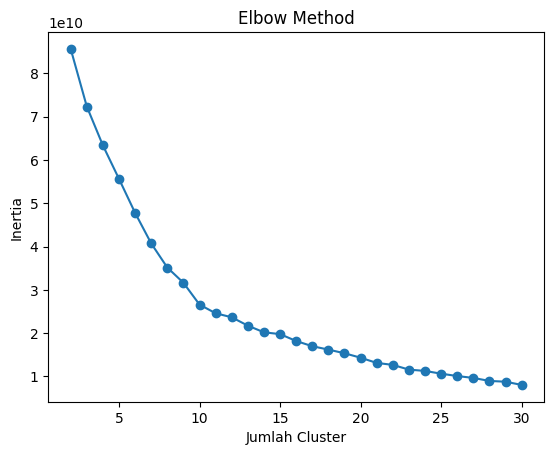

In [139]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D


# Elbow method
inertia = []
K = range(2, 31)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train)
    inertia.append(km.inertia_)

plt.figure()
plt.plot(K, inertia, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [140]:
k_opt = 10
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_train)

sil_score = silhouette_score(X_train, labels)
print(f"Silhouette Score (k={k_opt}): {sil_score:.4f}")

Silhouette Score (k=10): 0.7839


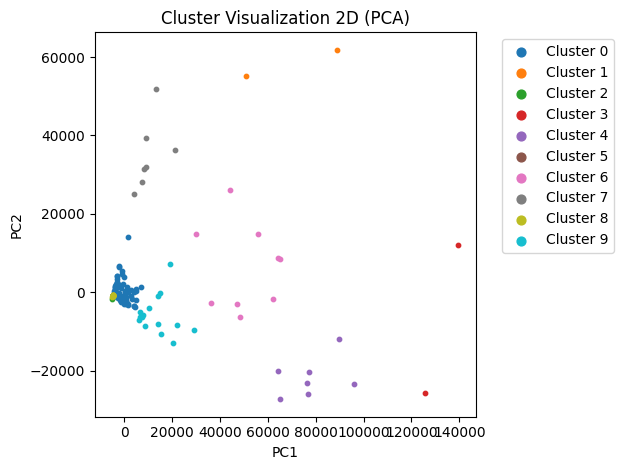

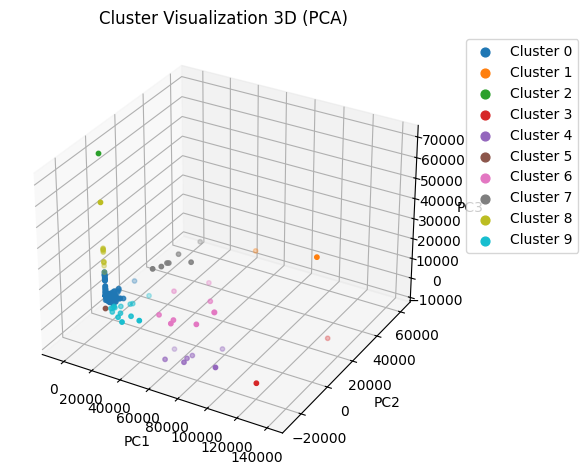

In [141]:
def visualize_clusters(X, labels):
    clusters = np.unique(labels)

    # ===== 2D PCA =====
    pca2 = PCA(n_components=2, random_state=42)
    X_2d = pca2.fit_transform(X)

    plt.figure()
    for c in clusters:
        idx = labels == c
        plt.scatter(X_2d[idx, 0], X_2d[idx, 1], s=10, label=f'Cluster {c}')

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Cluster Visualization 2D (PCA)')
    plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # ===== 3D PCA =====
    pca3 = PCA(n_components=3, random_state=42)
    X_3d = pca3.fit_transform(X)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    for c in clusters:
        idx = labels == c
        ax.scatter(
            X_3d[idx, 0],
            X_3d[idx, 1],
            X_3d[idx, 2],
            s=10,
            label=f'Cluster {c}'
        )

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title('Cluster Visualization 3D (PCA)')
    ax.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

visualize_clusters(X_train, labels)

In [142]:
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

X_train_cluster = kmeans.predict(X_train)
X_test_cluster = kmeans.predict(X_test)

X_train['cluster_id'] = X_train_cluster
X_test['cluster_id'] = X_test_cluster

In [143]:
print(X_train['cluster_id'].value_counts())
print(X_test['cluster_id'].value_counts())

cluster_id
0    455
9     15
8     10
6      9
7      7
4      7
1      2
3      2
5      1
2      1
Name: count, dtype: int64
cluster_id
0    201
9      7
7      3
8      2
1      2
4      1
3      1
6      1
2      1
Name: count, dtype: int64


In [146]:
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

In [147]:
models = {
    "DT": DecisionTreeClassifier(random_state=42),
    "RF": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    # "SVM": SVC(kernel='rbf', probability=True),
    # "KNN": KNeighborsClassifier(n_neighbors=5),
    # "LR": LogisticRegression(max_iter=1000, n_jobs=-1),
    "HGBC": HistGradientBoostingClassifier(random_state=42)
}

models.update({
    "LGBM": lgb.LGBMClassifier(
        objective='multiclass',
        num_class=len(set(y_enc)),
        n_estimators=300,
        learning_rate=0.05,
        random_state=42,
        verbosity=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        objective='multi:softprob',
        num_class=len(set(y_enc)),
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        eval_metric='mlogloss',
        random_state=42
    )
})

In [148]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0)
    })

In [149]:
results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False)
results_df

,model,accuracy,precision_macro,recall_macro,f1_macro
2,HGBC,0.598174,0.531442,0.511681,0.500306
5,XGBoost,0.607306,0.489230,0.490177,0.472907
3,LGBM,0.570776,0.440598,0.460207,0.429740
0,DT,0.529680,0.381887,0.387069,0.355533
1,RF,0.534247,0.362220,0.315733,0.320384
4,CatBoost,0.566210,0.328149,0.295707,0.292394


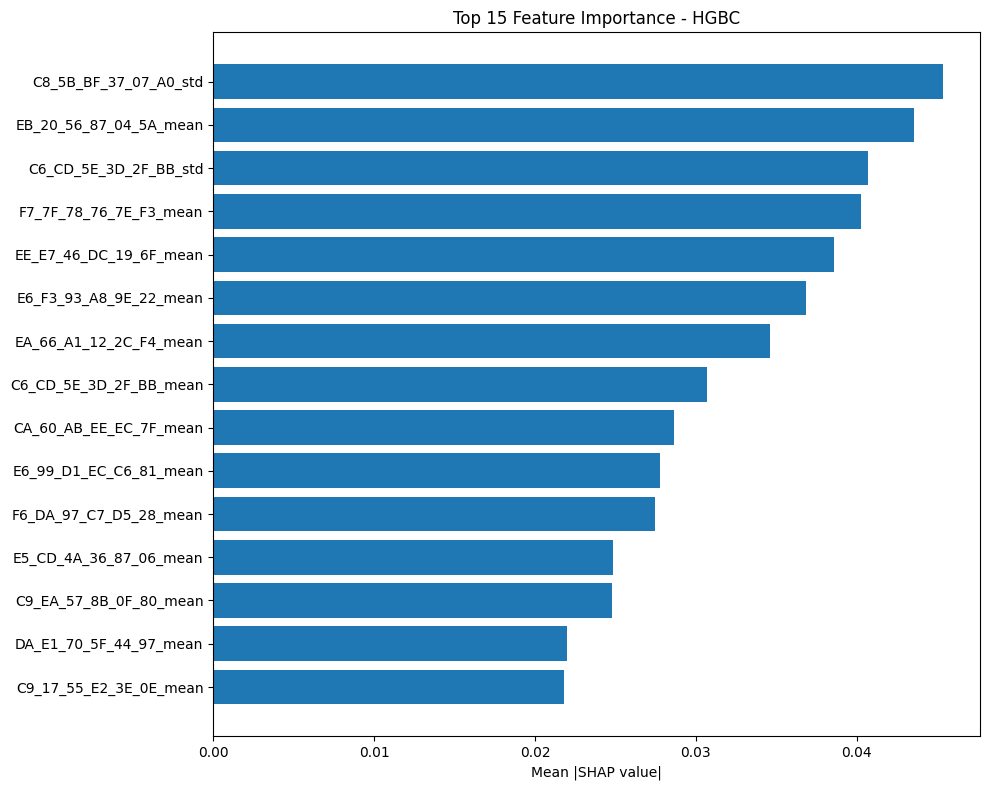

In [153]:
# Ambil best model
best_model_name = results_df.iloc[0]['model']
best_model = models[best_model_name]

# SHAP analysis dengan TreeExplainer
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Hitung mean absolute SHAP values (rata-rata semua kelas)
if isinstance(shap_values, list):
    shap_importance = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    shap_importance = np.abs(shap_values).mean(axis=(0,1))

# Ambil feature names
feature_names = X.columns if hasattr(X, 'columns') else [f'Feature_{i}' for i in range(X_test.shape[1])]

# Ambil 15 feature teratas
top_15_idx = np.argsort(shap_importance)[-15:]
top_15_features = [feature_names[i] for i in top_15_idx]
top_15_importance = shap_importance[top_15_idx]

# Visualisasi
plt.figure(figsize=(10, 8))
plt.barh(range(15), top_15_importance)
plt.yticks(range(15), top_15_features)
plt.xlabel('Mean |SHAP value|')
plt.title(f'Top 15 Feature Importance - {best_model_name}')
plt.tight_layout()
plt.show()